In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

conn = sqlite3.connect('../data/energy_capstone.db')

# pull annual oil prices from the database
df_fuel = pd.read_sql("""
    SELECT year, avg_crude_price
    FROM fuel_prices
    ORDER BY year
""", conn)

# prophet requires columns named ds (date) and y (value)
df_prophet = df_fuel.rename(columns={
    'year': 'ds',
    'avg_crude_price': 'y'
})

# convert year to datetime — prophet needs a proper date format
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'], format='%Y')

df_prophet.tail()

,ds,y
52,2022-01-01,97.101389
53,2023-01-01,80.755694
54,2024-01-01,78.733722
55,2025-01-01,63.807500
56,2026-01-01,70.783333


09:17:43 - cmdstanpy - INFO - Chain [1] start processing
09:17:44 - cmdstanpy - INFO - Chain [1] done processing


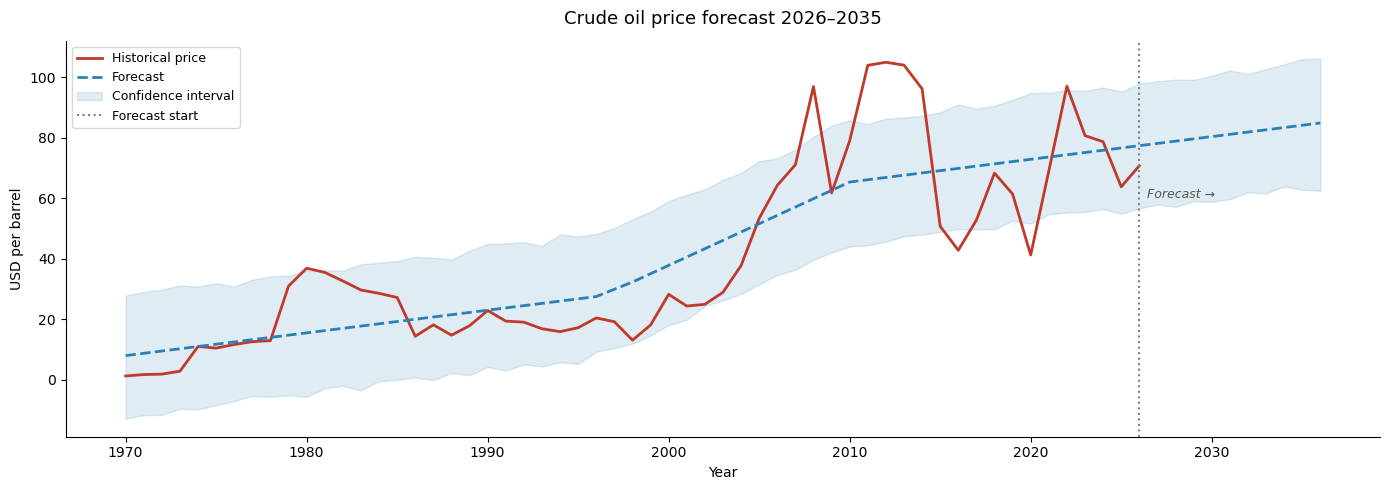

In [3]:
# train the model on historical data
model = Prophet(
    yearly_seasonality=False,  # annual data so no intra-year seasonality
    changepoint_prior_scale=0.3  # allows model to pick up sharp price shocks
)
model.fit(df_prophet)

# forecast 10 years into the future
future = model.make_future_dataframe(periods=10, freq='YE')
forecast = model.predict(future)

# plot the forecast
fig, ax = plt.subplots(figsize=(14, 5))

# historical prices
ax.plot(df_prophet['ds'], df_prophet['y'], 
        color='#c0392b', linewidth=2, label='Historical price')

# forecast line
ax.plot(forecast['ds'], forecast['yhat'], 
        color='#2980b9', linewidth=2, linestyle='--', label='Forecast')

# confidence interval
ax.fill_between(forecast['ds'], 
                forecast['yhat_lower'], 
                forecast['yhat_upper'],
                alpha=0.15, color='#2980b9', label='Confidence interval')

# mark where forecast begins
ax.axvline(pd.Timestamp('2026-01-01'), color='gray', 
           linestyle=':', linewidth=1.5, label='Forecast start')

ax.annotate('Forecast →', xy=(pd.Timestamp('2026-06-01'), 60),
            fontsize=9, color='#555', style='italic')

ax.set_title('Crude oil price forecast 2026–2035', fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('USD per barrel')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../data/oil_price_forecast.png', dpi=150)
plt.show()

In [4]:
# save forecast for Tableau
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    '../data/oil_price_forecast.csv', index=False
)

print("Forecast saved.")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

Forecast saved.
           ds       yhat  yhat_lower  yhat_upper
57 2026-12-31  78.158702   57.910966   98.757124
58 2027-12-31  78.909234   57.184010   99.252969
59 2028-12-31  79.661823   58.973723   99.206899
60 2029-12-31  80.412355   58.889606  100.533239
61 2030-12-31  81.162888   59.689842  102.300598
62 2031-12-31  81.913420   61.894416  101.148726
63 2032-12-31  82.666009   61.704567  102.791984
64 2033-12-31  83.416541   63.908324  104.321287
65 2034-12-31  84.167073   62.844964  106.078760
66 2035-12-31  84.917606   62.499531  106.205786


11:39:13 - cmdstanpy - INFO - Chain [1] start processing
11:39:13 - cmdstanpy - INFO - Chain [1] done processing


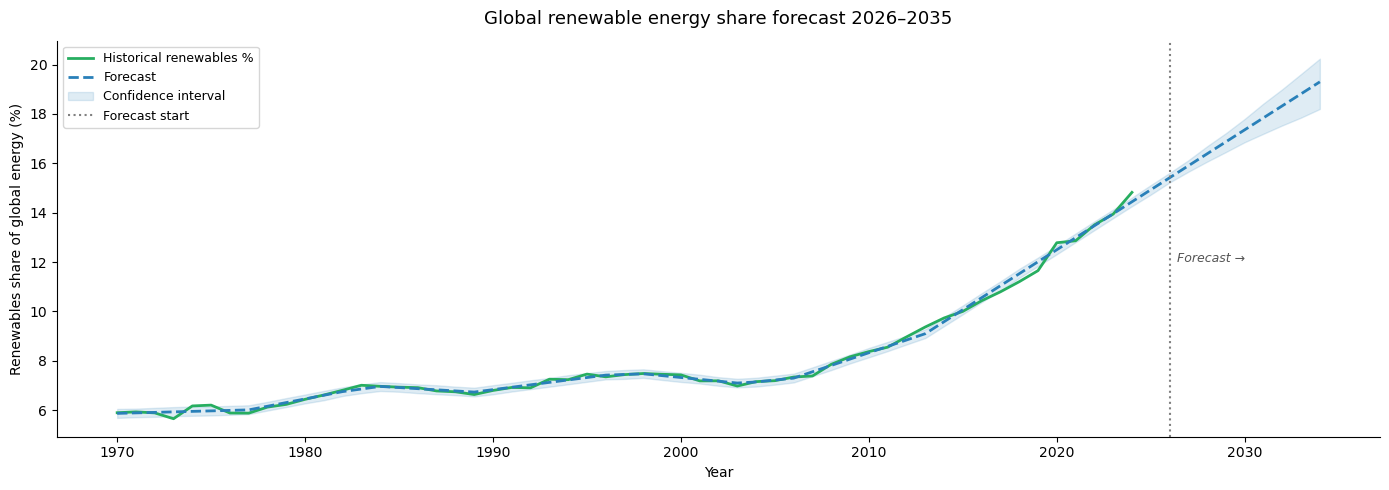

Renewables forecast saved.
           ds       yhat  yhat_lower  yhat_upper
55 2024-12-31  14.927229   14.729238   15.117487
56 2025-12-31  15.412931   15.221483   15.608691
57 2026-12-31  15.898634   15.656067   16.122158
58 2027-12-31  16.384336   16.065425   16.689323
59 2028-12-31  16.871369   16.456063   17.222037
60 2029-12-31  17.357072   16.854815   17.799411
61 2030-12-31  17.842774   17.196965   18.423011
62 2031-12-31  18.328476   17.534326   19.001351
63 2032-12-31  18.815509   17.852000   19.619181
64 2033-12-31  19.301212   18.202676   20.240483


In [5]:
import pandas as pd
import sqlite3
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/energy_capstone.db')

# pull world renewables share by year
df_ren = pd.read_sql("""
    SELECT 
        e.year,
        e.renewables_share_energy as renewables_pct
    FROM energy e
    WHERE e.country = 'World'
        AND e.year >= 1970
        AND e.renewables_share_energy IS NOT NULL
    ORDER BY e.year
""", conn)

# format for Prophet
df_ren_prophet = df_ren.rename(columns={
    'year': 'ds',
    'renewables_pct': 'y'
})
df_ren_prophet['ds'] = pd.to_datetime(df_ren_prophet['ds'], format='%Y')

# train the model
model_ren = Prophet(
    yearly_seasonality=False,
    changepoint_prior_scale=0.3
)
model_ren.fit(df_ren_prophet)

# forecast 10 years ahead
future_ren = model_ren.make_future_dataframe(periods=10, freq='YE')
forecast_ren = model_ren.predict(future_ren)

# plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_ren_prophet['ds'], df_ren_prophet['y'],
        color='#27ae60', linewidth=2, label='Historical renewables %')

ax.plot(forecast_ren['ds'], forecast_ren['yhat'],
        color='#2980b9', linewidth=2, linestyle='--', label='Forecast')

ax.fill_between(forecast_ren['ds'],
                forecast_ren['yhat_lower'],
                forecast_ren['yhat_upper'],
                alpha=0.15, color='#2980b9', label='Confidence interval')

ax.axvline(pd.Timestamp('2026-01-01'), color='gray',
           linestyle=':', linewidth=1.5, label='Forecast start')

ax.annotate('Forecast →', xy=(pd.Timestamp('2026-06-01'), 12),
            fontsize=9, color='#555', style='italic')

ax.set_title('Global renewable energy share forecast 2026–2035', fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Renewables share of global energy (%)')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../data/renewables_forecast.png', dpi=150)
plt.show()

# save for Tableau
forecast_ren[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    '../data/renewables_forecast.csv', index=False
)
print("Renewables forecast saved.")
print(forecast_ren[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))